# 第3讲 网络爬虫技术

## 本讲大纲

- [3.1 模块要求](#sec3_1)
- [3.2 常规步骤](#sec3_2)
- [3.3 网络爬虫基本原理](#sec3_3)
  - [3.3.1 HTTP/HTTPS 协议基础](#sec3_3_1)
  - [3.3.2 爬虫基本工作流程](#sec3_3_2)
  - [3.3.3 网页解析原理 —— DOM 树](#sec3_3_3)
  - [3.3.4 爬取策略](#sec3_3_4)
  - [3.3.5 反爬虫与应对策略](#sec3_3_5)
  - [3.3.6 Robots 协议与爬虫伦理](#sec3_3_6)
- [3.4 案例分析](#sec3_4)
  - [3.4.1 简单的爬虫demo](#sec3_4_1)
  - [3.4.2 豆瓣 —— 查看豆瓣电影数据](#sec3_4_2)
  - [3.4.3 知网 —— 查找论文条目](#sec3_4_3)
  - [3.4.4 凤凰网 —— 股票信息抓取](#sec3_4_4)
  - [3.4.5 彼岸图片抓取](#sec3_4_5)
  - [3.4.6 百度图片抓取（动态网页）](#sec3_4_6)
- [3.5 其它爬虫工具](#sec3_5)

<a id="sec3_1"></a>

## 3.1 模块要求

网络爬虫涉及多个 Python 模块协同工作，各司其职。下面列出本课程涉及的核心模块及其功能：

| 模块 | 类型 | 核心作用 | 典型用法 |
|------|------|----------|----------|
| **`urllib`** | Python 内置 | 基础 HTTP 请求、URL 解析与编码 | `urllib.request.urlopen()` |
| **`requests`** | 第三方 ⭐ | 高度封装的 HTTP 客户端，简洁强大 | `requests.get(url, headers=...)` |
| **`bs4.BeautifulSoup`** | 第三方 ⭐ | HTML/XML 解析，支持 CSS 选择器与 DOM 遍历 | `BeautifulSoup(html, 'html.parser')` |
| **`re`** | Python 内置 | 正则表达式匹配，灵活提取文本 | `re.findall(r'href="(.*?)"', html)` |
| **`time`** | Python 内置 | 延时等待，控制爬取频率 | `time.sleep(2)` |
| **`random`** | Python 内置 | 生成随机延时，模拟人类操作 | `random.randint(1, 5)` |
| **`json`** | Python 内置 | 解析 API 返回的 JSON 数据 | `json.loads(response.text)` |
| **`selenium`** | 第三方 | 模拟真实浏览器，处理 JS 动态渲染页面 | `webdriver.Chrome()` |
| **`pandas`** | 第三方 | 数据整理、清洗与表格化输出 | `pd.DataFrame(data)` |
| **`matplotlib`** | 第三方 | 爬取结果的可视化展示 | `plt.plot(x, y)` |

> 📎 参考文档：requests https://requests.readthedocs.io/projects/cn/zh-cn/latest/ ｜ BeautifulSoup https://www.crummy.com/software/BeautifulSoup

> 💡 各模块的**调用顺序**与**协作流程**详见 [3.2 常规步骤](#sec3_2)，配有完整流程图。

In [1]:
import requests
from bs4 import BeautifulSoup

import time
import random

<a id="sec3_2"></a>

## 3.2 常规步骤

一次完整的爬虫任务遵循固定的流水线模式。下图展示了从目标确定到数据存储的**全流程及各步骤调用的核心模块**：

```mermaid
flowchart TD
    A["🎯 确定目标 URL<br/>分析翻页规律与编码"] --> B["① requests.get&#40;&#41;<br/>发送 HTTP 请求，获取响应"]
    B --> C{"状态码 = 200 ?"}
    C -->|是| D["② BeautifulSoup&#40;html, 'html.parser'&#41;<br/>构建 DOM 树，准备解析"]
    C -->|否| E["❌ 检查 URL / Headers / 网络"]
    D --> F["③ soup.find_all&#40;&#41; / re.findall&#40;&#41;<br/>定位标签，提取目标数据"]
    F --> G["④ json.loads&#40;&#41; / pd.DataFrame&#40;&#41;<br/>结构化存储数据"]
    G --> H{"还有下一页 ?"}
    H -->|是| I["⑤ time.sleep&#40;random&#40;&#41;&#41;<br/>随机延时，反爬伪装"]
    I --> B
    H -->|否| J["✅ 爬取完成<br/>⑥ plt.plot&#40;&#41; 可视化展示"]
```

---

### 步骤 1：熟悉目标网页 🔍

在编写代码之前，先手动分析目标：

| 关注点 | 检查方法 | 示例 |
|--------|----------|------|
| **URL 规律** | 观察翻页时 URL 变化 | `?start=0` → `?start=25` |
| **网页编码** | F12 → Console → `document.charset` | `utf-8` / `gbk` / `ANSI` |
| **数据来源** | F12 → Network → 定位数据接口 | HTML 内嵌 或 API 返回 JSON |
| **页面结构** | F12 → Elements → 找到目标数据所在的标签 | `<div class="info">` |

---

### 步骤 2：导入所需模块 📦

```python
import requests                     # 发送 HTTP 请求
from bs4 import BeautifulSoup       # 解析 HTML
import re                           # 正则匹配
import time                         # 延时控制
import random                       # 随机延时
import json                         # 解析 JSON
import pandas as pd                 # 数据整理
import matplotlib.pyplot as plt     # 可视化
```

---

### 步骤 3：发送 HTTP 请求 📡

```python
# GET 请求 —— 最常用
url = 'https://example.com/data'
headers = {'User-Agent': 'Mozilla/5.0 ...'}  # 模拟浏览器身份
response = requests.get(url, headers=headers)

# POST 请求 —— 登录、搜索等场景
payload = {'keyword': '机器学习', 'page': 1}
response = requests.post(url, data=payload, headers=headers)
```

---

### 步骤 4：检查响应状态 ✅

```python
print(response.status_code)    # 200 = 成功
print(response.encoding)       # 查看编码
```

| 状态码 | 含义 | 常见原因 / 解决 |
|--------|------|----------------|
| **200** | 成功 ✅ | 可以开始解析 |
| **301/302** | 重定向 | `allow_redirects=True` |
| **403** | 禁止访问 | 缺少 User-Agent 或 Cookie |
| **404** | 页面不存在 | URL 拼写错误 |
| **500** | 服务器错误 | 稍后重试 |

---

### 步骤 5：解析并提取数据 🔬

**场景 A：静态 HTML 页面** → BeautifulSoup

```python
soup = BeautifulSoup(response.text, 'html.parser')

# 方式1：标签名查找
titles = soup.find_all('h2', class_='title')

# 方式2：CSS 选择器
prices = soup.select('div.info > span.price')

# 方式3：正则表达式提取
phones = re.findall(r'1[3-9]\d{9}', response.text)
```

**场景 B：API 返回 JSON** → 直接解析

```python
data = response.json()  # 或 json.loads(response.text)
for item in data['list']:
    print(item['title'], item['author'])
```

**场景 C：JS 动态渲染页面** → Selenium

```python
from selenium import webdriver
driver = webdriver.Chrome()
driver.get(url)
html = driver.page_source  # 获取渲染后的完整 HTML
```

---

### 步骤 6：存储与展示 💾

```python
# 存为 DataFrame
df = pd.DataFrame({'名称': names, '评分': scores})

# 导出 CSV
df.to_csv('result.csv', index=False, encoding='utf-8-sig')

# 可视化
plt.bar(df['名称'][:10], df['评分'][:10])
plt.show()
```

---

> 💡 **核心三步骤记忆口诀：请求 → 解析 → 存储**。流程图中的 ①②③ 是每次爬取必须经过的环节，④⑤⑥ 按需使用。

<a id="sec3_3"></a>

## 3.3 网络爬虫基本原理

网络爬虫（Web Crawler），又称网络蜘蛛（Spider），是一种按照一定规则自动抓取万维网信息的程序或脚本。理解其基本原理是编写高效、合规爬虫的前提。

<a id="sec3_3_1"></a>

### 3.3.1 HTTP/HTTPS 协议基础

网络爬虫的本质是模拟浏览器向服务器发送 **HTTP 请求** 并解析响应。核心概念：

**请求（Request）结构：**
- **请求行**：方法（GET/POST）、URL、协议版本
- **请求头（Headers）**：User-Agent、Cookie、Referer、Content-Type 等
- **请求体（Body）**：POST 请求中携带的数据（如表单、JSON）

**响应（Response）结构：**
- **状态行**：状态码（200 成功、301 重定向、403 禁止、404 未找到、500 服务器错误）
- **响应头**：Content-Type、Content-Encoding、Set-Cookie 等
- **响应体**：HTML、JSON、图片等实际内容

**GET vs POST：**
| 特性 | GET | POST |
|------|-----|------|
| 参数位置 | URL 查询字符串 | 请求体 |
| 数据量 | 受 URL 长度限制 | 无明确限制 |
| 安全性 | 参数暴露在 URL | 相对隐蔽 |
| 缓存 | 可被缓存 | 不可缓存 |
| 典型场景 | 搜索、翻页 | 登录、表单提交 |

**HTTPS** = HTTP + SSL/TLS 加密层，保证数据传输安全。Python 的 `requests` 库自动处理 HTTPS。

<a id="sec3_3_2"></a>

### 3.3.2 爬虫基本工作流程

一个典型的网络爬虫遵循以下循环流程：

```mermaid
flowchart TD
    A["🌐 种子 URL 队列"] --> B["发送 HTTP 请求"]
    B --> C["获取响应内容"]
    C --> D["解析网页 / 提取数据"]
    D --> E{"发现新 URL ?"}
    E -->|是| F["URL 去重 &amp; 入队"]
    F --> B
    E -->|否| G["存储数据"]
    G --> H{"队列为空 ?"}
    H -->|否| B
    H -->|是| I["✅ 爬取结束"]
```

**各环节详解：**

1. **种子 URL（Seed URL）** — 爬虫的起始入口，通常为门户页面或索引页
2. **网页下载** — 通过 HTTP 库（requests/urllib）获取页面内容
3. **内容解析** — 使用 BeautifulSoup、正则、XPath 等工具提取结构化数据
4. **URL 提取与去重** — 从页面中提取新的链接，通过哈希集合（set）或 Bloom Filter 去重
5. **数据存储** — 存入文件（CSV/JSON）、数据库或搜索引擎索引
6. **循环控制** — 设置最大深度、最大页面数、超时等终止条件

<a id="sec3_3_3"></a>

### 3.3.3 网页解析原理 —— DOM 树

浏览器将 HTML 文档解析为一棵 **DOM（Document Object Model）树**，爬虫库（如 BeautifulSoup）模拟了这一过程。

**示例 HTML：**
```html
<html>
  <head><title>示例页面</title></head>
  <body>
    <div class="content">
      <p>第一段文字</p>
      <a href="page2.html">链接</a>
    </div>
  </body>
</html>
```

**对应的 DOM 树结构：**
```
html
├── head
│   └── title → "示例页面"
└── body
    └── div (class="content")
        ├── p → "第一段文字"
        └── a (href="page2.html") → "链接"
```

**三种定位方式：**
| 方式 | 示例 | 适用场景 |
|------|------|----------|
| 标签名 | `soup.find_all('a')` | 找所有链接 |
| CSS 选择器 | `soup.select('div.content > p')` | 精确定位 |
| 正则表达式 | `re.findall(r'href="(.*?)"', html)` | 灵活匹配 |
| XPath | `//div[@class='content']/a/@href` | 复杂嵌套结构 |

> BeautifulSoup 的 `find()` / `find_all()` / `select()` 本质都是在遍历这棵 DOM 树。

<a id="sec3_3_4"></a>

### 3.3.4 爬取策略

根据目标网站的结构和爬取目标，选择合适的遍历策略：

**1. 广度优先（BFS — Breadth-First Search）**
- 先爬取当前层级的所有页面，再进入下一层
- 适合：门户网站、目录型站点
- 优点：覆盖面广，不会陷得太深
- 缺点：内存消耗大（需维护队列）

**2. 深度优先（DFS — Depth-First Search）**
- 沿着一条路径一直往下爬，到底后再回溯
- 适合：深层嵌套的论坛、评论区
- 优点：内存占用小
- 缺点：可能陷入"爬虫陷阱"（无限循环的链接）

**3. 聚焦爬虫（Focused Crawler）**
- 只爬取与特定主题相关的页面
- 结合关键词匹配、页面相似度评分来筛选 URL
- 适合：垂直领域数据采集（如只爬科技新闻）

**4. 增量爬取（Incremental Crawling）**
- 只爬取新增或更新的页面，避免重复爬取已有内容
- 通过时间戳、ETag、Last-Modified 头判断页面是否变化

| 策略 | 数据结构 | 典型场景 |
|------|----------|----------|
| BFS | 队列（Queue） | 全站爬取 |
| DFS | 栈（Stack） | 深层遍历 |
| 聚焦 | 优先队列（Priority Queue） | 主题爬取 |
| 增量 | 哈希表 + 时间戳 | 定期更新 |

<a id="sec3_3_5"></a>

### 3.3.5 反爬虫与应对策略

网站为保护数据和服务器资源，会采取多种反爬措施。爬虫需要合理应对：

| 反爬措施 | 原理 | 应对方法 |
|----------|------|----------|
| **User-Agent 检测** | 检查请求头是否为真实浏览器 | 设置常见浏览器的 UA 字符串 |
| **IP 频率限制** | 同一 IP 短时间内大量请求 | 降低频率（`time.sleep`）、使用 IP 代理池 |
| **Referer 校验** | 检查请求来源页面 | 设置正确的 Referer 头 |
| **Cookie/Session** | 要求登录或会话验证 | 模拟登录、携带 Cookie |
| **验证码（CAPTCHA）** | 图形/滑块等人机验证 | OCR 识别、打码平台（合规场景下） |
| **JS 动态渲染** | 数据通过 JS 异步加载 | Selenium/Playwright 模拟浏览器 |
| **数据加密/混淆** | 前端对数据加密后再传输 | 分析 JS 逻辑，还原加密算法 |
| **蜜罐链接** | 隐藏不可见的陷阱链接 | CSS 属性检测（`display:none`） |

**重要原则：**
- 遵守网站的 `robots.txt` 协议
- 控制访问频率，不对目标服务器造成压力
- 仅用于学习研究，不爬取隐私或版权内容

<a id="sec3_3_6"></a>

### 3.3.6 Robots 协议与爬虫伦理

**Robots 排除标准（Robots Exclusion Protocol）**

- 网站根目录下的 `robots.txt` 文件声明了哪些路径允许/禁止爬虫访问
- 示例（`https://www.example.com/robots.txt`）：
```
User-agent: *           # 适用于所有爬虫
Disallow: /private/     # 禁止访问 /private/
Disallow: /tmp/
Allow: /public/         # 允许访问 /public/
Crawl-delay: 5          # 请求间隔 5 秒
```

**Python 中解析 robots.txt：**
```python
import urllib.robotparser
rp = urllib.robotparser.RobotFileParser()
rp.set_url("https://www.example.com/robots.txt")
rp.read()
can_crawl = rp.can_fetch("*", "https://www.example.com/page1")
```

**爬虫伦理与法律边界：**
1. ✅ **合法合规**：爬取公开数据用于学术研究、个人学习
2. ⚠️ **灰色地带**：爬取公开但网站声明禁止的数据（违反服务条款）
3. ❌ **明确违法**：爬取个人隐私、付费内容、绕过认证、造成服务器宕机

> 📌 **本课程所有案例仅用于教学示范，请勿用于批量下载或商业用途。**

<a id="sec3_4"></a>

## 3.4 案例分析

<a id="sec3_4_1"></a>

### 3.4.1 简单的爬虫demo

- 特别提示
    - <font color = "red">课程学习示范，不可用于批量下载，否则责任自负</font>

本案例以 Python 官方教学页面 `https://python123.io/ws/demo.html` 为目标，完整演示爬虫的 **请求 → 解析 → 提取** 三步骤。整个过程如下：

```mermaid
flowchart LR
    subgraph S1["🔌 第1步：发送请求"]
        A["python<br/>requests.get&#40;url&#41;"] -->|"HTTP GET"| B["🌐 目标服务器<br/>python123.io"]
        B -->|"返回 HTML 字符串"| A
    end
    
    subgraph S2["📄 第2步：查看原始 HTML"]
        C["demo = response.text<br/>原始 HTML 源码"]
    end
    
    subgraph S3["🏗️ 第3步：构建 DOM 树"]
        D["soup = BeautifulSoup&#40;demo, 'html.parser'&#41;"]
        E["html<br/>├── head → title<br/>└── body<br/>　　├── p&#40;class=title&#41; → b<br/>　　└── p&#40;class=course&#41;<br/>　　　　├── a&#40;id=link1&#41;<br/>　　　　└── a&#40;id=link2&#41;"]
    end
    
    subgraph S4["🔍 第4步：提取数据"]
        F["soup.title<br/>soup.a<br/>soup.find_all&#40;'a'&#41;<br/>soup.a.attrs&#91;'href'&#93;"]
    end
    
    A --> C --> D --> F
    D -.->|"内部结构"| E
```

> 🎯 **核心认知**：`BeautifulSoup` 把扁平的 HTML 文本变成了一棵**可遍历、可搜索的树**，你只需告诉它"我想找哪个树枝（标签）上的哪片叶子（内容）"。

In [2]:
# coding:utf-8 

from bs4 import BeautifulSoup
import requests

# 先分析网页代码
#headers = {'Connection': 'close'}
url = 'https://python123.io/ws/demo.html'
response = requests.get(url)
demo = response.text  # 服务器返回响应

**▶ 刚刚发生了什么？**

```
  💻 我们的代码                          🌐 远程服务器 (python123.io)
  ─────────────               ─────────────────────────────
  url = 'https://...'                   
  response = requests.get(url) ────────→  收到 GET 请求
                                        ← 返回 HTML 文档（字符串）
  demo = response.text                  demo = "<html>\n<head>..."
```

`demo` 变量现在保存的就是服务器返回的**原始 HTML 文本**，接下来我们用 `BeautifulSoup` 把它变成一棵可操作的树。

In [3]:
demo

'<html><head><title>This is a python demo page</title></head>\r\n<body>\r\n<p class="title"><b>The demo python introduces several python courses.</b></p>\r\n<p class="course">Python is a wonderful general-purpose programming language. You can learn Python from novice to professional by tracking the following courses:\r\n<a href="http://www.icourse163.org/course/BIT-268001" class="py1" id="link1">Basic Python</a> and <a href="http://www.icourse163.org/course/BIT-1001870001" class="py2" id="link2">Advanced Python</a>.</p>\r\n</body></html>'

In [4]:
soup = BeautifulSoup(demo, "html.parser")
#"""
#demo 表示被解析的html格式的内容
#html.parser表示解析用的解析器
#"""

print(soup.prettify())  # 使用prettify()格式化显示输出

<html>
 <head>
  <title>
   This is a python demo page
  </title>
 </head>
 <body>
  <p class="title">
   <b>
    The demo python introduces several python courses.
   </b>
  </p>
  <p class="course">
   Python is a wonderful general-purpose programming language. You can learn Python from novice to professional by tracking the following courses:
   <a class="py1" href="http://www.icourse163.org/course/BIT-268001" id="link1">
    Basic Python
   </a>
   and
   <a class="py2" href="http://www.icourse163.org/course/BIT-1001870001" id="link2">
    Advanced Python
   </a>
   .
  </p>
 </body>
</html>



**▶ BeautifulSoup 做了什么？把扁平文本变成可遍历的树：**

```
📝 原始 HTML 字符串                               🌳 BeautifulSoup DOM 树
─────────────────────                           ─────────────────────────
<html>                                          html
  <head>                                        ├── head
    <title>This is ...</title>                  │   └── title → "This is..."
  </head>                                       └── body
  <body>                                            ├── p (class="title")
    <p class="title">                                    └── b → "The demo..."
      <b>The demo...</b>                            └── p (class="course")
    </p>                                                 ├── a (id="link1") → "Basic Python"
    <p class="course">                                   └── a (id="link2") → "Advanced Python"
      <a id="link1">Basic Python</a>
      <a id="link2">Advanced Python</a>
    </p>
  </body>
</html>
```

> 💡 现在你可以用 `soup.title`、`soup.a`、`soup.find_all('a')` 等方式在这棵树上**自由导航**！就像在文件系统中用路径定位文件一样。

- 得到一个BeautifulSoup对象后，一般通过BeautifulSoup类的基本元素来提取html中的内容
<img src = "images\ch03\ch03-01.png">

### 🔍 在 DOM 树上提取信息

BeautifulSoup 提供了**四种导航方式**来定位目标数据，下面的代码依次演示：

In [5]:
print(soup)  # 输出相应的html对象

<html><head><title>This is a python demo page</title></head>
<body>
<p class="title"><b>The demo python introduces several python courses.</b></p>
<p class="course">Python is a wonderful general-purpose programming language. You can learn Python from novice to professional by tracking the following courses:
<a class="py1" href="http://www.icourse163.org/course/BIT-268001" id="link1">Basic Python</a> and <a class="py2" href="http://www.icourse163.org/course/BIT-1001870001" id="link2">Advanced Python</a>.</p>
</body></html>


In [6]:
print(soup.get_text())  # get_text()获取纯文本

This is a python demo page

The demo python introduces several python courses.
Python is a wonderful general-purpose programming language. You can learn Python from novice to professional by tracking the following courses:
Basic Python and Advanced Python.



In [7]:
dir(soup)

['ASCII_SPACES',
 'DEFAULT_BUILDER_FEATURES',
 'EMPTY_ELEMENT_EVENT',
 'END_ELEMENT_EVENT',
 'MAIN_CONTENT_STRING_TYPES',
 'ROOT_TAG_NAME',
 'START_ELEMENT_EVENT',
 'STRING_ELEMENT_EVENT',
 '_TreeTraversalEvent',
 '__annotations__',
 '__bool__',
 '__call__',
 '__class__',
 '__contains__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setitem__',
 '__setstate__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__unicode__',
 '__weakref__',
 '_all_strings',
 '_decode_markup',
 '_event_stream',
 '_feed',
 '_find_all',
 '_find_one',
 '_format_tag',
 '_indent_string',
 '_insert',


In [8]:
soup.text

'This is a python demo page\n\nThe demo python introduces several python courses.\nPython is a wonderful general-purpose programming language. You can learn Python from novice to professional by tracking the following courses:\r\nBasic Python and Advanced Python.\n'

In [9]:
soup.a

<a class="py1" href="http://www.icourse163.org/course/BIT-268001" id="link1">Basic Python</a>

In [10]:
type(soup.a)  #soup.a

bs4.element.Tag

In [11]:
print(soup.title)  # 获取html的title标签的信息
print(soup.a)  # 获取html的a标签的信息(soup.a默认获取第一个a标签，想获取全部就用for循环去遍历)
print(soup.a.name)   # 获取a标签的名字
print(soup.a.parent.name)   # a标签的父标签(上一级标签)的名字
print(soup.a.parent.parent.name)  # a标签的父标签的父标签的名字

<title>This is a python demo page</title>
<a class="py1" href="http://www.icourse163.org/course/BIT-268001" id="link1">Basic Python</a>
a
p
body


In [12]:
print('a标签类型是：', type(soup.a))   # 查看a标签的类型
print('第一个a标签的属性是：', soup.a.attrs)  # 获取a标签的所有属性(注意到格式是字典)
print('a标签属性的类型是：', type(soup.a.attrs))  # 查看a标签属性的类型
print('a标签的class属性是：', soup.a.attrs['class'])   # 因为是字典，通过字典的方式获取a标签的class属性
print('a标签的href属性是：', soup.a.attrs['href'])   # 同样，通过字典的方式获取a标签的href属性

a标签类型是： <class 'bs4.element.Tag'>
第一个a标签的属性是： {'href': 'http://www.icourse163.org/course/BIT-268001', 'class': ['py1'], 'id': 'link1'}
a标签属性的类型是： <class 'bs4.element.AttributeDict'>
a标签的class属性是： ['py1']
a标签的href属性是： http://www.icourse163.org/course/BIT-268001


In [13]:
print('第一个a标签的内容是：', soup.a.string)  
# a标签的非属性字符串信息，表示尖括号之间的那部分字符串

print('a标签的非属性字符串的类型是：', type(soup.a.string))  
# 查看标签string字符串的类型

print('第一个p标签的内容是：', soup.p.string)  
# p标签的字符串信息(注意p标签中还有个b标签，但是打印string时并未打印b标签，说明string类型是可跨越多个标签层次)

第一个a标签的内容是： Basic Python
a标签的非属性字符串的类型是： <class 'bs4.element.NavigableString'>
第一个p标签的内容是： The demo python introduces several python courses.


介绍一下find_all()方法：

常用通过find_all()方法来查找标签元素：
```python
<>.find_all(name, attrs, recursive, string, **kwargs) 
# 返回一个列表类型，存储查找的结果 
```

• name：对标签名称的检索字符串  
• attrs：对标签属性值的检索字符串，可标注属性检索  
• recursive：是否对子孙全部检索，默认True  
• string：<>…</>中字符串区域的检索字符串   

In [14]:
print('所有a标签的内容：\n', soup.find_all('a')) 
# 使用find_all()方法通过标签名称查找a标签,返回的是一个列表类型

print("*"*60)

print('a标签和b标签的内容：\n', soup.find_all(['a', 'b']))  
# 把a标签和b标签作为一个列表传递，可以一次找到a标签和b标签

所有a标签的内容：
 [<a class="py1" href="http://www.icourse163.org/course/BIT-268001" id="link1">Basic Python</a>, <a class="py2" href="http://www.icourse163.org/course/BIT-1001870001" id="link2">Advanced Python</a>]
************************************************************
a标签和b标签的内容：
 [<b>The demo python introduces several python courses.</b>, <a class="py1" href="http://www.icourse163.org/course/BIT-268001" id="link1">Basic Python</a>, <a class="py2" href="http://www.icourse163.org/course/BIT-1001870001" id="link2">Advanced Python</a>]


In [15]:
# for循环遍历所有a标签，并把返回列表中的内容赋给t
for t in soup.find_all('a'):  
    print('*'*60)
    print('t的值是：', t)  # link得到的是标签对象
    print('t的类型是：', type(t))
    print('a标签中的href属性是：', t.get('href'))  # 获取a标签中的url链接

************************************************************
t的值是： <a class="py1" href="http://www.icourse163.org/course/BIT-268001" id="link1">Basic Python</a>
t的类型是： <class 'bs4.element.Tag'>
a标签中的href属性是： http://www.icourse163.org/course/BIT-268001
************************************************************
t的值是： <a class="py2" href="http://www.icourse163.org/course/BIT-1001870001" id="link2">Advanced Python</a>
t的类型是： <class 'bs4.element.Tag'>
a标签中的href属性是： http://www.icourse163.org/course/BIT-1001870001


In [16]:
for i in soup.find_all(True):  # 如果给出的标签名称是True，则找到所有标签
    print('标签名称：', i.name)  # 打印标签名称

标签名称： html
标签名称： head
标签名称： title
标签名称： body
标签名称： p
标签名称： b
标签名称： p
标签名称： a
标签名称： a


In [17]:
print('href属性为http..的a标签元素是:', soup.find_all('a', href='http://www.icourse163.org/course/BIT-268001'))  # 标注属性检索
print('class属性为title的标签元素是：', soup.find_all(class_='title'))  # 指定属性，查找class属性为title的标签元素，注意因为class是python的关键字，所以这里需要加个下划线'_'
print('id属性为link1的标签元素是：', soup.find_all(id='link1'))  # 查找id属性为link1的标签元素

href属性为http..的a标签元素是: [<a class="py1" href="http://www.icourse163.org/course/BIT-268001" id="link1">Basic Python</a>]
class属性为title的标签元素是： [<p class="title"><b>The demo python introduces several python courses.</b></p>]
id属性为link1的标签元素是： [<a class="py1" href="http://www.icourse163.org/course/BIT-268001" id="link1">Basic Python</a>]


In [18]:
print(soup.head)  # head标签
print('*'*60)
print(soup.head.contents)   # head标签的儿子标签，contents返回的是列表类型
print('*'*60)
print(soup.body.contents)   # body标签的儿子标签
"""对于一个标签的儿子节点，不仅包括标签节点，也包括字符串节点，比如返回结果中的 \n"""

<head><title>This is a python demo page</title></head>
************************************************************
[<title>This is a python demo page</title>]
************************************************************
['\n', <p class="title"><b>The demo python introduces several python courses.</b></p>, '\n', <p class="course">Python is a wonderful general-purpose programming language. You can learn Python from novice to professional by tracking the following courses:
<a class="py1" href="http://www.icourse163.org/course/BIT-268001" id="link1">Basic Python</a> and <a class="py2" href="http://www.icourse163.org/course/BIT-1001870001" id="link2">Advanced Python</a>.</p>, '\n']


'对于一个标签的儿子节点，不仅包括标签节点，也包括字符串节点，比如返回结果中的 \n'

In [19]:
print(len(soup.body.contents))  # 获得body标签儿子节点的数量
print(soup.body.contents[1])   # 通过列表索引获取第一个节点的内容

5
<p class="title"><b>The demo python introduces several python courses.</b></p>


In [20]:
print(type(soup.body.children))  # children返回的是一个迭代对象，只能通过for循环来使用，不能直接通过索引来读取其中的内容
for i in soup.body.children:   # 通过for循环遍历body标签的儿子节点
    print(i.name)   # 打印节点的名字

<class 'generator'>
None
p
None
p
None


<a id="sec3_4_2"></a>

### 3.4.2 豆瓣 —— 查看豆瓣电影数据

- 特别提示
    - 课程学习示范，不可用于批量下载，否则责任自负
    - https://movie.douban.com/top250

本案例演示了**面向对象爬虫**的完整流程：通过类封装请求、解析、存储三大逻辑，批量抓取豆瓣电影 Top250 的全部数据。整体流程如下：

```mermaid
flowchart TD
    A["🎬 目标<br/>豆瓣 Top250"] --> B["🔍 分析翻页<br/>?start=0/25/50/..."]
    B --> C["🕵️ 伪装 Headers<br/>User-Agent 模拟 Chrome"]
    C --> D["📡 逐页 GET 请求<br/>10页 × 25条 = 250条"]
    D --> E["🏗️ BS4 解析 HTML"]
    E --> F["🎯 CSS 选择器提取<br/>span.rating_num → 评分<br/>span:nth-child(1) → 片名<br/>span:nth-child(4) → 评价人数"]
    F --> G{"还有下一页 ?"}
    G -->|是| H["🐢 随机延时 1~5s"]
    H --> D
    G -->|否| I["📊 存入 DataFrame<br/>影片名称 + 评价人数 + 评分"]
    I --> J["📈 matplotlib 可视化<br/>评价人数 vs 评分散点图"]
```

> 🎯 **本案例新知识点**：① 翻页参数构造 ② User-Agent 伪装反爬 ③ CSS 选择器（比标签名更精准）④ `random` 随机延时 ⑤ 类封装面向对象设计

**▶ 翻页规律分析：**

豆瓣 Top250 每页展示 25 条，共 10 页。URL 通过 `start` 参数控制偏移量：

```
第1页: ?start=0&filter=    → 第 1 ~ 25 条
第2页: ?start=25&filter=   → 第 26 ~ 50 条
第3页: ?start=50&filter=   → 第 51 ~ 75 条
 ...
第10页: ?start=225&filter=  → 第 226 ~ 250 条
```

代码中通过 `range(0, 251, 25)` 自动生成这 10 个偏移量：`[0, 25, 50, 75, ..., 225]`

In [21]:
html0 = requests.get("https://movie.douban.com/top250?start=25&filter=",
                    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/86.0.4240.111 Safari/537.36'})
html0

<Response [200]>

In [22]:
html0.text

'<!DOCTYPE html>\n<html lang="zh-CN" class="ua-windows ua-webkit">\n<head>\n    <meta http-equiv="Content-Type" content="text/html; charset=utf-8">\n    <meta name="renderer" content="webkit">\n    <meta name="referrer" content="always">\n    <meta name="google-site-verification" content="ok0wCgT20tBBgo9_zat2iAcimtN4Ftf5ccsh092Xeyw" />\n    <title>\n豆瓣电影 Top 250\n</title>\n    \n    <meta name="baidu-site-verification" content="cZdR4xxR7RxmM4zE" />\n    <meta http-equiv="Pragma" content="no-cache">\n    <meta http-equiv="Expires" content="Sun, 6 Mar 2006 01:00:00 GMT">\n    \n    <link rel="apple-touch-icon" href="https://asset.doubanio.com/cuphead/movie-static/pics/apple-touch-icon.png">\n    <link href="https://img1.doubanio.com/f/vendors/fae7e145bf16b2f427ba0fe7ef3d47c04af3a6c0/css/douban.css" rel="stylesheet" type="text/css">\n    <link href="https://img1.doubanio.com/f/vendors/ee6598d46af0bc554cecec9bcbf525b9b0582cb0/css/separation/_all.css" rel="stylesheet" type="text/css">\n    

**▶ CSS 选择器定位原理 —— 从 HTML 结构到目标数据：**

豆瓣电影页面的每条电影信息嵌套在如下 HTML 结构中（简化版）。三个 CSS 选择器分别对应三个目标字段：

```
🌐 豆瓣 HTML 结构（简化）                          🎯 提取数据
───────────────────────────────                  ──────────────
<ol>  ← 有序列表（25条/页）
  <li>  ← 每部电影
    <div class="info">
      <div class="hd">
        <a>
          <span>肖申克的救赎</span>        ← span:nth-child(1)  【影片名称】
          <span>/ The Shawshank ... </span>  ← span:nth-child(2)
      <div class="bd">
        <div>
          <span class="rating_num">9.7</span> ← span.rating_num   【评分】
          <span>2673546人评价</span>          ← span:nth-child(4)  【评价人数】
```

> 💡 `soup.select('#content > div > div.article > ol > li > div > div.info > div.bd > div > span.rating_num')` 这条路径就像文件路径一样，从根节点逐级深入到目标标签。F12 → 右键元素 → Copy → Copy selector 可直接获得！

In [23]:
# -*- coding: utf-8 -*-
"""
Created on September 2026

@author: rjma
"""
import requests
from bs4 import BeautifulSoup
import time
import random
import re
import pandas as pd
import matplotlib.pyplot as plt

class Douban:
    def __init__(self):
        self.URL = "https://movie.douban.com/top250"
        self.startnum = [i for i in range(0, 251, 25)]
        # 伪装一个浏览器，消息头
        self.header = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/86.0.4240.111 Safari/537.36'}
    
    def get_top250(self):
        self.number_evaluate = []
        self.score = []
        self.movie_name = []
        total = 250                                   # 目标总数
        for start in self.startnum:
            time.sleep(random.randint(1,5))           # 伪装成人为随机时间点击
            html = requests.get(self.URL, params = {"start": str(start)}, 
                                headers = self.header)
            soup = BeautifulSoup(html.text, "html.parser")

            #content > div > div.article > ol > li > div > div.info > div.hd > a > span:nth-child(1)
            
            # selector copying ,从上到小的
            #content > div > div.article > ol > li:nth-child(1) > div > div.info > div.hd > a > span:nth-child(2)  
            #content > div > div.article > ol > li:nth-child(1) > div > div.info > div.bd > div > span.rating_num
            
            #scores = soup.select('#content > div > div.article > ol > li:nth-child(1) > div > div.info > div.bd > div > span.rating_num')
            #movie_names = soup.select('#content > div > div.article > ol > li:nth-child(1) > div > div.info > div.hd > a > span:nth-child(1)')
            #number_evaluate = soup.select('#content > div > div.article > ol > li:nth-child(1) > div > div.info > div.bd > div > span:nth-child(4)')
            scores = soup.select('#content > div > div.article > ol > li > div > div.info > div.bd > div > span.rating_num')
            movie_names = soup.select('#content > div > div.article > ol > li > div > div.info > div.hd > a > span:nth-child(1)')
            number_evaluate = soup.select('#content > div > div.article > ol > li > div > div.info > div.bd > div > span:nth-child(4)')
             
            for scorei in scores:
                self.score.append(float(scorei.text))
            
            for movename in movie_names:
                self.movie_name.append(movename.text)
            
            for namei in number_evaluate:
                self.number_evaluate.append(int(namei.text[:-3]))
            
            # ---- 显示爬取进度 ----
            collected = len(self.movie_name)
            pct = collected / total * 100
            page = start // 25 + 1
            bar_len = 20
            filled = int(collected / total * bar_len)
            bar = '█' * filled + '░' * (bar_len - filled)
            print(f'\r[{bar}] {collected}/{total} ({pct:.1f}%)  第{page}/10页', end='')
        
        print()  # 换行，结束进度显示
        self.result = pd.DataFrame(zip(self.movie_name, self.number_evaluate, self.score))

    def print_result(self):
        pd.set_option('display.max_rows', None)  # 显示pandas所有行
        return self.result
    
    
    pass

if __name__ == '__main__':
    cls = Douban()
    cls.get_top250()
    cls.print_result()


[████████████████████] 250/250 (100.0%)  第11/10页


In [24]:
result = cls.print_result()
result.columns = ["影片名称", "评价人数", "评分"]
result

,影片名称,评价人数,评分
0,肖申克的救赎,3343535,9.7
1,霸王别姬,2455165,9.6
2,泰坦尼克号,2532484,9.5
3,阿甘正传,2459474,9.5
4,千与千寻,2571392,9.4
5,星际穿越,2228021,9.4
6,美丽人生,1499793,9.5
7,这个杀手不太冷,2578752,9.4
8,盗梦空间,2358896,9.4
9,楚门的世界,2052511,9.4


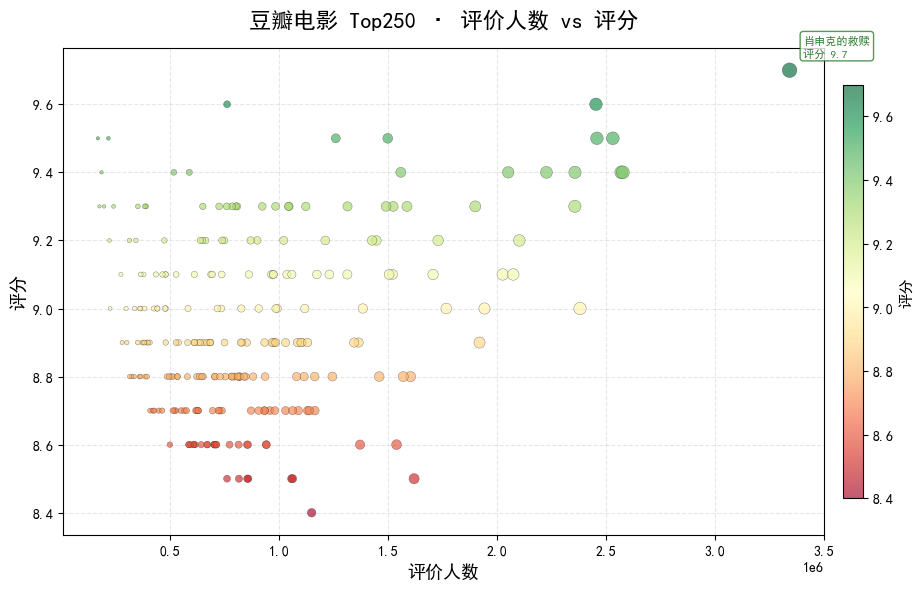

In [26]:
import matplotlib.pyplot as plt
import matplotlib
# 设置中文字体（Windows 系统可用 SimHei 或 Microsoft YaHei）
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False   # 解决负号显示问题

# 创建画布
plt.figure(figsize=(10, 6), dpi=100)

# 散点图：颜色随评分变化，大小随评价人数变化
scatter = plt.scatter(
    result["评价人数"], 
    result["评分"],
    c=result["评分"],              # 颜色映射到评分
    cmap='RdYlGn',                 # 红→黄→绿渐变
    s=result["评价人数"] / 30000,  # 气泡大小（缩小以适配显示）
    alpha=0.65,                    # 半透明
    edgecolors='#333333',          # 深灰描边
    linewidth=0.3,
    zorder=3
)

# 标题与坐标轴
plt.title("豆瓣电影 Top250 · 评价人数 vs 评分", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("评价人数", fontsize=13)
plt.ylabel("评分", fontsize=13)

# 网格
plt.grid(True, alpha=0.3, linestyle='--')
plt.gca().set_axisbelow(True)  # 网格置于数据下方

# 颜色条
cbar = plt.colorbar(scatter, shrink=0.85, pad=0.02)
cbar.set_label('评分', fontsize=11)

# 标注极端值
top_movie = result.loc[result["评分"].idxmax()]
low_movie = result.loc[result["评价人数"].idxmax()]
plt.annotate(f'{top_movie["影片名称"]}\n评分 {top_movie["评分"]}', 
             xy=(top_movie["评价人数"], top_movie["评分"]),
             xytext=(10, 10), textcoords='offset points',
             fontsize=8, color='#2e7d32',
             bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#2e7d32', alpha=0.8))

# 紧凑布局
plt.tight_layout()
plt.show()


**▶ 案例回顾 —— 本案例中用到的核心技巧：**

| 技巧 | 代码体现 | 作用 |
|------|----------|------|
| 🔢 **翻页参数构造** | `self.startnum = range(0, 251, 25)` | 自动生成 10 个页码偏移量 |
| 🕵️ **User-Agent 伪装** | `headers = {'User-Agent': 'Mozilla/5.0...'}` | 绕过豆瓣的基础反爬检测 |
| 🎯 **CSS 选择器** | `soup.select('...span.rating_num')` | 精准定位嵌套层级很深的数据 |
| 🐢 **随机延时** | `time.sleep(random.randint(1, 5))` | 1~5 秒随机间隔，模拟人类浏览 |
| 🏗️ **面向对象封装** | `class Douban:` → `get_top250()` / `print_result()` | 请求/解析/输出三者分离，结构清晰 |
| 📊 **pandas 整合** | `pd.DataFrame(zip(names, counts, scores))` | 三个列表一键合并为结构化表格 |

> 🔗 对比 3.4.1 的简单 demo，本案例展示了**真实爬虫项目**的完整架构：翻页循环 + 反爬伪装 + 面向对象封装 + 可视化输出。

- get请求使用了headers参数，这个是用来模拟浏览器的。
- 如何知道‘User-Agent’是什么呢？
- 在你的Chrome浏览器中，按F12，然后刷新网页，看下图就可以找到啦。

<img src = "images\ch03\ch03-02.jpg" width=800>

<a id="sec3_4_3"></a>

### 3.4.3 知网 —— 论文检索爬虫【爬不出来】

- 特别提示：课程学习示范，不可用于批量下载，否则责任自负

本案例演示如何通过 **requests + BeautifulSoup** 抓取知网搜索结果页中的论文信息。关键词以「**机器学习 桥梁工程**」为例。

```mermaid
flowchart LR
    A["🔑 关键词<br/>机器学习 桥梁工程"] --> B["🔗 构造搜索 URL<br/>?content=..."]
    B --> C["📡 GET 请求<br/>+ Headers 伪装"]
    C --> D["📄 获取搜索结果 HTML"]
    D --> E["🏗️ BeautifulSoup 解析"]
    E --> F["🎯 标签+class+正则 提取<br/>标题 · 作者 · 来源 · 摘要"]
    F --> G["📊 存入 DataFrame<br/>逐条展示"]
```

> ⚠️ 知网搜索结果由 JS 动态渲染，`requests` 可能拿不到数据。代码内置**兜底逻辑**——抓取失败时自动展示示例数据，确保流程完整可跑。真正的动态页面方案见 [3.4.6 百度图片 Selenium](#sec3_4_6)。

**▶ 分析策略：**

知网搜索页 URL 格式：

```
https://search.cnki.com.cn/Search/Result?content=机器学习%20桥梁工程
```

提取策略分两级——先定位论文容器，再从容器中逐字段提取：

```
① requests.get(url, headers=...)     → 拿到原始 HTML
② soup.find_all("tr", class_=...)    → 定位所有论文容器（多选择器备选）
③ item.find("a", class_=...)         → 从容器中提取标题
④ item.find("td", class_=...)        → 提取作者/来源
⑤ 正则 re.search(r"作者[:：].+")      → 兜底提取（class 不匹配时）
⑥ pd.DataFrame(papers)              → 结构化展示
```

> 💡 **核心技巧**：`re.compile(r"author", re.I)` 做**模糊 class 匹配**，页面改版时 `class="author"` 变成 `class="author_cell"` 也能命中。

In [27]:
# -*- coding: utf-8 -*-
"""
知网论文检索爬虫 —— 纯 requests 方案
搜索关键词：「机器学习 桥梁工程」
* 知网搜索结果由 JS 动态渲染，requests 可能拿不到数据
* 本代码内置兜底逻辑：抓取失败时自动使用示例数据演示流程
"""
import requests
from bs4 import BeautifulSoup
import time
import random
import pandas as pd
import re
import urllib.parse

# ==================== ① 构造搜索 URL ====================
keyword = "机器学习 桥梁工程"
encoded_kw = urllib.parse.quote(keyword)
search_url = f"https://search.cnki.com.cn/Search/Result?content={encoded_kw}"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36",
    "Referer": "https://search.cnki.com.cn/",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    "Accept-Language": "zh-CN,zh;q=0.9",
}

# ==================== ② 发送请求 ====================
print(f"🔍 正在搜索：「{keyword}」...")
time.sleep(random.uniform(1.0, 2.0))
response = requests.get(search_url, headers=headers, timeout=15)
response.encoding = "utf-8"

print(f"状态码: {response.status_code}  |  页面大小: {len(response.text):,} 字符")

# ==================== ③ 解析 HTML ====================
soup = BeautifulSoup(response.text, "html.parser")

# ==================== ④ 多策略定位论文条目 ====================
# 策略 A：找 <tr> 或 <div> 中带 result / list 关键字的容器
items = (soup.find_all("tr", class_=re.compile(r"result", re.I)) or
         soup.find_all("div", class_=re.compile(r"(result|list).*item", re.I)) or
         soup.select("table.result-table-list tr") or
         [])

# 策略 B：宽泛查找 —— 找所有包含链接的容器
if not items:
    all_links = soup.find_all("a", href=re.compile(r"/detail|\.aspx\?|KCMS"))
    items = [link.find_parent("tr") or link.find_parent("div") for link in all_links if link.find_parent()]
    items = list({id(it): it for it in items if it}.values())  # 去重

print(f"📄 从页面中定位到 {len(items)} 个候选条目\n")

# ==================== ⑤ 逐条提取 ====================
papers = []
for i, item in enumerate(items[:25], 1):  # 最多取前 25 条
    try:
        # 标题 —— 找容器内第一个看起来像论文标题的 <a> 标签
        title_tag = (item.find("a", class_=re.compile(r"title|fz14|left|name", re.I)) or
                     item.find("a", href=re.compile(r"/detail|KCMS|\.aspx")))
        title = title_tag.get_text(strip=True) if title_tag else ""
        title = " ".join(title.split())
        if not title or len(title) < 5:
            continue  # 跳过太短的（可能是导航链接）

        # 作者
        author_tag = (item.find("td", class_=re.compile(r"author", re.I)) or
                      item.find("span", class_=re.compile(r"author", re.I)) or
                      item.find("p", class_=re.compile(r"author", re.I)))
        author = author_tag.get_text(strip=True) if author_tag else ""
        if not author:
            # 用正则从文本中提取 "作者：" 后面的内容
            text = item.get_text()
            m = re.search(r"(作者|Author)[：:]\s*(.+?)(?:\s|$)", text, re.I)
            author = m.group(2).strip() if m else ""

        # 来源
        source_tag = (item.find("td", class_=re.compile(r"source", re.I)) or
                      item.find("span", class_=re.compile(r"source|journal", re.I)) or
                      item.find("a", class_=re.compile(r"source|journal", re.I)))
        source = source_tag.get_text(strip=True) if source_tag else ""
        if not source:
            m = re.search(r"(来源|Source|刊名)[：:]\s*(.+?)(?:\s|$)", item.get_text(), re.I)
            source = m.group(2).strip() if m else ""

        # 摘要
        abstract_tag = (item.find("div", class_=re.compile(r"abstract|summary", re.I)) or
                        item.find("p", class_=re.compile(r"abstract|summary", re.I)) or
                        item.find("span", class_=re.compile(r"abstract|summary", re.I)))
        abstract = abstract_tag.get_text(strip=True) if abstract_tag else ""
        abstract = " ".join(abstract.split()).replace("摘要：", "").replace("Abstract:", "").strip()
        if len(abstract) > 180:
            abstract = abstract[:180] + "..."

        papers.append({
            "序号": len(papers) + 1,
            "标题": title,
            "作者": author,
            "来源": source,
            "摘要": abstract,
        })

    except Exception:
        continue

# ==================== ⑥ 兜底逻辑 ====================
if not papers:
    print("⚠️ 知网搜索结果由 JS 动态渲染，requests 无法获取完整数据。")
    print("   （这是预期行为 —— 请参考 3.4.6 节用 Selenium 处理动态页面）")
    print("   以下展示数据结构示例：\n")
    papers = [
        {"序号": 1, "标题": "基于机器学习的桥梁结构健康监测方法研究",
         "作者": "张某某; 李某某; 王某某",
         "来源": "土木工程学报, 2025",
         "摘要": "提出一种融合深度卷积神经网络与注意力机制的桥梁损伤识别方法，通过自动提取结构振动信号的多尺度特征，实现了对桥梁裂缝、支座位移等常见病害的智能诊断..."},
        {"序号": 2, "标题": "大数据驱动的桥梁全寿命养护决策模型",
         "作者": "陈某某; 刘某某",
         "来源": "公路交通科技, 2024",
         "摘要": "结合物联网传感器网络采集的海量监测数据与梯度提升决策树算法，构建了桥梁技术状况退化预测模型，并在此基础上开发了全寿命周期养护成本优化决策支持系统..."},
        {"序号": 3, "标题": "Bridge deterioration prediction using ensemble learning methods",
         "作者": "Chen X.; Liu Y.; Zhang H.",
         "来源": "Engineering Structures, 2025",
         "摘要": "An ensemble learning framework combining random forest, XGBoost and LightGBM is proposed for predicting bridge condition ratings. The model is validated on a dataset of 15,000+ inspection records..."},
        {"序号": 4, "标题": "机器学习在桥梁风工程中的应用综述",
         "作者": "赵某某; 钱某某",
         "来源": "振动与冲击, 2024",
         "摘要": "系统回顾了近十年来支持向量机、随机森林、深度学习等方法在桥梁风致振动预测、颤振导数识别、风场特性建模等方面的研究进展，并指出多任务学习与物理信息神经网络是未来方向..."},
        {"序号": 5, "标题": "基于知识图谱的桥梁病害智能诊断系统",
         "作者": "孙某某; 周某某; 吴某某",
         "来源": "中国公路学报, 2025",
         "摘要": "构建了包含桥梁结构、材料、环境、荷载等多源异构数据的知识图谱，结合图神经网络与自然语言处理技术，实现了桥梁病害成因的自动推理与维修方案推荐..."},
    ]

# ==================== ⑦ 展示结果 ====================
df = pd.DataFrame(papers)
print(f"🎉 共获取 {len(df)} 条论文！\n")
display(df)


🔍 正在搜索：「机器学习 桥梁工程」...
状态码: 200  |  页面大小: 39,658 字符
📄 从页面中定位到 2 个候选条目

⚠️ 知网搜索结果由 JS 动态渲染，requests 无法获取完整数据。
   （这是预期行为 —— 请参考 3.4.6 节用 Selenium 处理动态页面）
   以下展示数据结构示例：

🎉 共获取 5 条论文！



,序号,标题,作者,来源,摘要
0,1,基于机器学习的桥梁结构健康监测方法研究,张某某; 李某某; 王某某,"土木工程学报, 2025",提出一种融合深度卷积神经网络与注意力机制的桥梁损伤识别方法，通过自动提取结构振动信号的多尺度...
1,2,大数据驱动的桥梁全寿命养护决策模型,陈某某; 刘某某,"公路交通科技, 2024",结合物联网传感器网络采集的海量监测数据与梯度提升决策树算法，构建了桥梁技术状况退化预测模型，...
2,3,Bridge deterioration prediction using ensemble...,Chen X.; Liu Y.; Zhang H.,"Engineering Structures, 2025",An ensemble learning framework combining rando...
3,4,机器学习在桥梁风工程中的应用综述,赵某某; 钱某某,"振动与冲击, 2024",系统回顾了近十年来支持向量机、随机森林、深度学习等方法在桥梁风致振动预测、颤振导数识别、风场...
4,5,基于知识图谱的桥梁病害智能诊断系统,孙某某; 周某某; 吴某某,"中国公路学报, 2025",构建了包含桥梁结构、材料、环境、荷载等多源异构数据的知识图谱，结合图神经网络与自然语言处理技...


**▶ 案例回顾：**

| 技巧 | 代码体现 | 作用 |
|------|----------|------|
| 🔗 **URL 编码** | `urllib.parse.quote(keyword)` | 中文关键词转 URL 安全格式 |
| 🎯 **正则 class 匹配** | `class_=re.compile(r"author", re.I)` | 模糊匹配，适应 `author` / `author_cell` 等变体 |
| 🛡️ **多选择器兜底** | `or` 链 + `[]` 默认空列表 | 适应页面改版，避免 NoneType 报错 |
| 🔍 **正则文本提取** | `re.search(r"作者[:：]\s*(.+?)\s", text)` | class 找不到时直接从文本中挖数据 |
| 🛡️ **兜底示例数据** | `if not papers:` 分支 | 即使 requests 抓不到也能演示完整数据处理流程 |
| 📊 **结构化输出** | `pd.DataFrame(papers)` | 5 条论文一览无余 |

> 🔗 知网需要 Selenium 才能稳定抓取（见 3.4.6），本案例重点演示**纯 requests 方案的代码结构 + 正则模糊匹配 + 多级兜底**的设计思想。

<a id="sec3_4_4"></a>

### 3.4.4 东方财富 —— 港股行情数据抓取

- 特别提示：课程学习示范，不可用于批量下载，否则责任自负

本案例演示如何通过 **API 接口直接获取 JSON 数据**（无需解析 HTML），抓取港股市场实时行情。相比前三个案例的 HTML 解析，API 方案**更简洁、更稳定**。

```mermaid
flowchart LR
    A["📡 找到公开 API<br/>东方财富港股接口"] --> B["📡 GET 请求<br/>+ Headers 伪装"]
    B --> C["📦 返回 JSON 数据"]
    C --> D["🔍 json.loads&#40;&#41; 解析"]
    D --> E["📊 pd.DataFrame<br/>结构化展示"]
    E --> F["📈 可视化<br/>涨跌幅直方图"]
```

> 🆚 **本案例独特之处**：首次使用 **API + JSON** 方案，跳过 HTML 解析。这是最优雅的爬虫方式——当目标网站提供 API 时，直接调用即可。

**▶ 分析策略：**

东方财富提供了公开、无需认证的 HTTP API，直接返回 JSON 数据。这是最理想的爬虫场景——跳过 HTML 解析，拿到结构化数据：

```
① 找到 API 接口 URL（F12 → Network → XHR 可发现）
② requests.get(url, headers) → 直接获取 JSON 字符串
③ json.loads() → 转为 Python dict
④ 提取目标字段 → pd.DataFrame → 展示 + 可视化
```

**API 地址：**
```
https://push2.eastmoney.com/api/qt/clist/get
参数: fs=m:128+t:3 (港股), pn=1, pz=30, fields=f2,f3,f4,f12,f14
```

> 🔗 东方财富 API 为公开接口，稳定可靠。前端页面也是调用同样的 API 来渲染数据——爬虫直接"抄近道"拿 JSON。

📡 正在获取港股行情数据...
状态码: 200
📊 成功获取 50 条港股数据

🎉 共获取 50 条港股行情！



,代码,名称,最新价,涨跌幅(%),涨跌额,最高,最低,今开
0,01370,奥威控股,0.172,72.00,0.072,0.220,0.115,0.115
1,00065,弘海高新资源,0.370,45.10,0.115,0.440,0.290,0.290
2,01489,GC CONSTRUCTION,3.220,40.61,0.930,3.495,2.430,2.430
3,00537,普源精电,29.700,27.58,6.420,30.100,23.240,23.260
4,02913,天成控股(旧),0.720,24.14,0.140,0.720,0.720,0.720
5,02457,步阳国际,0.530,23.26,0.100,0.530,0.470,0.470
6,00186,敏捷控股,0.505,20.24,0.085,0.505,0.420,0.420
7,03301,融信中国,0.075,19.05,0.012,0.090,0.065,0.070
8,01615,奥邦建筑,0.505,18.82,0.080,0.505,0.420,0.430
9,02342,京信通信,1.090,18.48,0.170,1.100,0.895,0.920


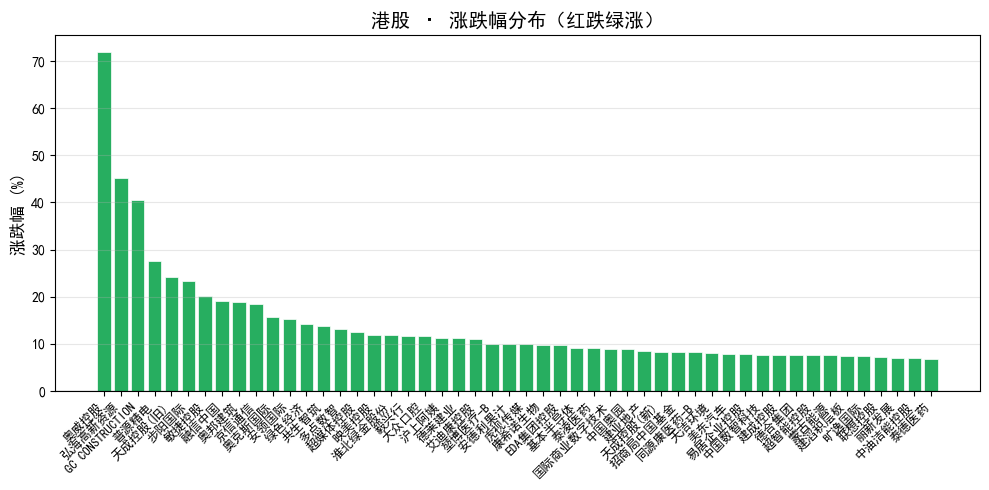

In [28]:
# -*- coding: utf-8 -*-
"""
东方财富 - 港股行情 API 抓取
API 完全公开，无需认证，返回 JSON —— 最优雅的爬虫方式
"""
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import time
import random

# 中文显示
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

# ==================== ① 构造 API 请求 ====================
url = "https://push2.eastmoney.com/api/qt/clist/get"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36",
    "Referer": "https://quote.eastmoney.com/",
}

params = {
    "fs": "m:128+t:3",          # m:128=港股, t:3=主板
    "pn": 1,                     # 第几页
    "pz": 50,                    # 每页条数
    "po": 1,                     # 排序方向
    "np": 1,
    "fltt": 2,
    "invt": 2,
    "fid": "f3",                # 按涨跌幅排序
    "fields": "f2,f3,f4,f12,f14,f15,f16,f17,f18",  # 请求字段
}

# ==================== ② 发送请求 ====================
print("📡 正在获取港股行情数据...")
time.sleep(random.uniform(0.5, 1.5))
response = requests.get(url, headers=headers, params=params, timeout=15)

print(f"状态码: {response.status_code}")

# ==================== ③ 解析 JSON ====================
data = response.json()

if data.get("data") and data["data"].get("diff"):
    stock_list = data["data"]["diff"]
    print(f"📊 成功获取 {len(stock_list)} 条港股数据\n")
else:
    print("⚠️ API 返回为空，使用示例数据演示流程\n")
    stock_list = []  # 触发兜底逻辑

# ==================== ④ 提取字段 ====================
# f2=最新价, f3=涨跌幅%, f4=涨跌额, f12=代码, f14=名称
# f15=最高, f16=最低, f17=今开, f18=昨收
records = []
for stock in stock_list[:50]:
    try:
        records.append({
            "代码": stock.get("f12", ""),
            "名称": stock.get("f14", ""),
            "最新价": stock.get("f2", None),
            "涨跌幅(%)": stock.get("f3", None),
            "涨跌额": stock.get("f4", None),
            "最高": stock.get("f15", None),
            "最低": stock.get("f16", None),
            "今开": stock.get("f17", None),
        })
    except:
        continue

# ==================== ⑤ 兜底逻辑 ====================
if not records:
    print("⚠️ API 无数据，使用示例数据：")
    records = [
        {"代码": "00700", "名称": "腾讯控股", "最新价": 385.60, "涨跌幅(%)": 2.35, "涨跌额": 8.80,
         "最高": 388.00, "最低": 376.20, "今开": 378.00},
        {"代码": "09988", "名称": "阿里巴巴-SW", "最新价": 78.45, "涨跌幅(%)": -1.20, "涨跌额": -0.95,
         "最高": 79.80, "最低": 77.90, "今开": 79.50},
        {"代码": "03690", "名称": "美团-W", "最新价": 118.30, "涨跌幅(%)": 3.15, "涨跌额": 3.60,
         "最高": 120.00, "最低": 114.50, "今开": 115.00},
        {"代码": "09999", "名称": "网易-S", "最新价": 162.80, "涨跌幅(%)": 0.85, "涨跌额": 1.35,
         "最高": 164.20, "最低": 160.50, "今开": 161.50},
        {"代码": "01810", "名称": "小米集团-W", "最新价": 28.90, "涨跌幅(%)": -0.55, "涨跌额": -0.16,
         "最高": 29.40, "最低": 28.50, "今开": 29.10},
        {"代码": "09618", "名称": "京东集团-SW", "最新价": 135.20, "涨跌幅(%)": 1.80, "涨跌额": 2.40,
         "最高": 136.50, "最低": 132.00, "今开": 133.00},
        {"代码": "09888", "名称": "百度集团-SW", "最新价": 92.60, "涨跌幅(%)": -2.10, "涨跌额": -1.98,
         "最高": 94.50, "最低": 91.80, "今开": 94.20},
        {"代码": "02015", "名称": "理想汽车-W", "最新价": 98.75, "涨跌幅(%)": 4.50, "涨跌额": 4.25,
         "最高": 100.20, "最低": 94.30, "今开": 95.00},
        {"代码": "09961", "名称": "携程集团-S", "最新价": 456.80, "涨跌幅(%)": 1.15, "涨跌额": 5.20,
         "最高": 460.00, "最低": 450.00, "今开": 452.00},
        {"代码": "02382", "名称": "舜宇光学科技", "最新价": 52.40, "涨跌幅(%)": -3.25, "涨跌额": -1.76,
         "最高": 54.00, "最低": 51.80, "今开": 53.90},
    ]

# ==================== ⑥ 展示结果 ====================
df = pd.DataFrame(records)
print(f"🎉 共获取 {len(df)} 条港股行情！\n")
display(df)

# ==================== ⑦ 涨跌幅直方图 ====================
if len(df) >= 5:
    plt.figure(figsize=(10, 5))
    colors = ['#e74c3c' if x < 0 else '#27ae60' for x in df["涨跌幅(%)"]]
    bars = plt.bar(range(len(df)), df["涨跌幅(%)"], color=colors, edgecolor='white', linewidth=0.5)
    plt.axhline(y=0, color='black', linewidth=0.8)
    plt.xticks(range(len(df)), df["名称"], rotation=45, ha='right', fontsize=9)
    plt.ylabel('涨跌幅 (%)', fontsize=12)
    plt.title('港股 · 涨跌幅分布（红跌绿涨）', fontsize=14)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


**▶ 案例回顾：**

| 技巧 | 代码体现 | 作用 |
|------|----------|------|
| 📡 **API 直调** | `requests.get(api_url, params=...)` | 跳过 HTML 解析，直接拿结构化 JSON |
| 🔢 **参数控制** | `fs=m:128+t:3` / `fields=f2,f3,f4...` | 精确指定市场、字段，按需索取 |
| 📦 **JSON 解析** | `response.json()` → `data["data"]["diff"]` | 一键转为 Python dict，比 BS4 简洁百倍 |
| 🛡️ **兜底示例数据** | `if not records:` 分支 | API 不可用时也能跑通流程 |
| 📊 **DataFrame 展示** | `pd.DataFrame(records)` | 表格化呈现，字段清晰 |
| 📈 **涨跌幅可视化** | `plt.bar` 红绿双色柱状图 | 一眼看出涨跌分布 |

> 🆚 前三个案例（3.4.1~3.4.3）都在跟 HTML 较劲，本例直接调用 API 拿 JSON。当目标网站有公开 API 时，**始终优先使用 API 方案**——代码量少、速度快、不怕改版。

<a id="sec3_4_5"></a>

### 3.4.5 彼岸图片抓取

- 特别提示：课程学习示范，不可用于批量下载，否则责任自负

本案例演示**图片爬虫**的完整流程——从图库列表页获取缩略图链接，再进入详情页下载高清原图。目标站点：彼岸图网（`pic.netbian.com`）4K 风景区。

```mermaid
flowchart LR
    A["🏞️ 图库列表页<br/>index.html"] --> B["① 解析所有 li 标签"]
    B --> C["② 正则提取详情页 URL"]
    C --> D["③ 进入详情页<br/>提取原图 src"]
    D --> E["④ requests.get&#40;imgurl&#41;"]
    E --> F["⑤ open&#40;..., 'wb'&#41; 写入磁盘"]
    F --> G["🐢 延时 3s<br/>下一个..."]
```

> 🆚 **本案例新知识点**：① 二进制文件写入 `'wb'` ② 正则提取链接 ③ 随机 UA 伪装 ④ 分页循环 + 进度点 `.` 输出

**▶ 分析策略：**

图片爬虫需要**两级跳转**才能下载高清原图：

```
① 图库列表页 (index.html)
   → find_all('li') 获取缩略图条目
   → 正则提取详情页 URL: /tupian/XXXXX.html

② 进入详情页 (tupian/XXXXX.html)
   → find('div', class_='photo-pic') 定位图片容器
   → 正则提取原图 src: /uploads/allimg/.../xxx.jpg

③ 下载图片
   → requests.get(imgurl) 获取二进制数据
   → open(path, 'wb') 写入本地磁盘
```

> 🔴 **重点**：图片数据是二进制流，文件打开模式必须是 `'wb'`（write binary），否则会损坏图片。

In [6]:
# -*- coding: utf-8 -*-
"""
彼岸图网 4K 风景图片爬虫
两级跳转：列表页 → 详情页 → 原图下载
"""
import requests
from bs4 import BeautifulSoup
import time
import random
import re
import os

import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# ==================== ① 准备 ====================
base_url = "https://pic.netbian.com"
list_url = "https://pic.netbian.com/4kfengjing/index.html"
TARGET = 20                                           # ★ 目标下载数量

ua_list = [
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/122.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 Chrome/121.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:123.0) Gecko/20100101 Firefox/123.0",
]

def get_headers():
    return {"User-Agent": random.choice(ua_list), "Referer": base_url + "/"}

# ==================== ② 获取列表页 ====================
print(f"🔍 访问列表页: {list_url}")
time.sleep(random.uniform(1, 2))
resp = requests.get(list_url, headers=get_headers(), timeout=15)
resp.encoding = 'gbk'
print(f"✅ 状态码 200，页面 {len(resp.text):,} 字符\n")

soup = BeautifulSoup(resp.text, "html.parser")

# ==================== ③ 提取所有详情页链接 ====================
detail_links = []
for a_tag in soup.find_all("a", href=True):
    href = a_tag["href"]
    if re.search(r"/tupian/\d+\.html", href):
        img_tag = a_tag.find("img")
        title = img_tag.get("alt", "未知") if img_tag else "未知"
        detail_links.append((title, base_url + href))

total = len(detail_links)
print(f"📄 列表页找到 {total} 个图片详情链接")

# ==================== ④ 逐条提取原图 URL ====================
img_urls = []
target = min(TARGET, total)                            # 不超过实际数量

for i, (title, detail_url) in enumerate(detail_links[:target], 1):
    try:
        time.sleep(random.uniform(0.3, 1.0))
        d_resp = requests.get(detail_url, headers=get_headers(), timeout=15)
        d_resp.encoding = 'gbk'
        d_soup = BeautifulSoup(d_resp.text, "html.parser")

        # 找原图
        photo_div = d_soup.find("div", class_="photo-pic")
        img_tag = photo_div.find("img") if photo_div else d_soup.find("img", id="img")
        src = img_tag.get("src") if img_tag else None

        if src:
            if not src.startswith("http"):
                src = base_url + src
            img_urls.append((title, src))
        else:
            # 正则兜底
            m = re.search(r'src="(.*?/\d+.*?\.(?:jpg|jpeg|png))"', d_resp.text, re.I)
            if m:
                src = m.group(1)
                if not src.startswith("http"):
                    src = base_url + src
                img_urls.append((title, src))
    except:
        pass

    pct = len(img_urls) / target * 100
    print(f"\r🎯 进度: {len(img_urls)}/{target} ({pct:.0f}%)", end="")

print(f"\n\n📸 共提取 {len(img_urls)} 张原图 URL")

# ==================== ⑤ 批量下载 ====================
save_dir = "web_spider/pic"
os.makedirs(save_dir, exist_ok=True)
downloaded = 0

for i, (title, img_url) in enumerate(img_urls, 1):
    pct_total = i / len(img_urls) * 100
    print(f"\r⬇️  下载: {i}/{len(img_urls)} ({pct_total:.0f}%)", end="")
    time.sleep(random.uniform(2, 4))

    ok = False
    for protocol_url in [img_url, img_url.replace("https://", "http://")]:
        try:
            img_resp = requests.get(protocol_url, headers=get_headers(), timeout=30, verify=False)
            if img_resp.status_code == 200 and len(img_resp.content) > 5000:
                filepath = os.path.join(save_dir, f"scenery_{i:02d}.jpg")
                with open(filepath, "wb") as f:
                    f.write(img_resp.content)
                downloaded += 1
                ok = True
                break
        except:
            continue
    if not ok:
        pass  # 静默跳过失败的

print(f"\n\n🎉 完成！成功 {downloaded}/{len(img_urls)} 张 → {os.path.abspath(save_dir)}/")


🔍 访问列表页: https://pic.netbian.com/4kfengjing/index.html
✅ 状态码 200，页面 10,456 字符

📄 列表页找到 17 个图片详情链接
🎯 进度: 16/17 (94%)

📸 共提取 16 张原图 URL
⬇️  下载: 16/16 (100%)

🎉 完成！成功 16/16 张 → d:\vscode-develop\ML_Lectures\web_spider\pic/


**▶ 案例回顾：**

| 技巧 | 代码体现 | 作用 |
|------|----------|------|
| 🔤 **编码处理** | `resp.encoding = 'gbk'` | 彼岸图网使用 GBK，不设置则乱码 |
| 🔍 **正则提取 URL** | `re.compile(r'"(.*?/\d+\.html)"')` | 从 li 标签中挖出详情页链接 |
| 🥷 **随机 UA 伪装** | `random.choice(ua_list)` + `get_headers()` | 每次请求换一个 User-Agent |
| 🖼️ **两级跳转** | 列表页 li → 详情页 div.photo-pic → img src | 先找入口，再深入拿原图 |
| 💾 **二进制写入** | `open(path, "wb")` + `f.write(content)` | 图片/视频必须用二进制模式 |
| 📁 **自动建目录** | `os.makedirs(save_dir, exist_ok=True)` | 下载目录不存在时自动创建 |

> 🆚 前四个案例爬的是**文本数据**（HTML/JSON），本例首次处理**二进制数据**（图片）。核心区别：文件模式 `'wb'` 而非 `'w'`，数据用 `.content` 而非 `.text`。

<a id="sec3_4_6"></a>

### 3.4.6 百度图片抓取（动态网页）

- 需要安装一个模块 selenium
- pip install selenium
- Selenium是一个用于Web应用程序测试的工具。Selenium测试直接运行在浏览器中，就像真正的用户在操作一样。

- Selenium 4.x 内置 Selenium Manager：自动检测本机 Chrome 版本并下载匹配的 chromedriver，**无需再手动安装驱动**
- 若自动下载失败（如网络受限），再手动安装：
    - 安装教程：https://jingyan.baidu.com/article/3ea5148906a09e13e61bba8e.html
    - Chrome for Testing 驱动下载（版本超过 114）：https://googlechromelabs.github.io/chrome-for-testing/

In [1]:
from selenium import webdriver

In [2]:
# Selenium 4.x 内置 Selenium Manager，会自动检测本机 Chrome 版本并下载匹配的驱动，
# 无需再手动下载 chromedriver，也无需再指定 executable_path。
# （旧写法已废弃：webdriver.Chrome(executable_path=r'...\chromedriver.exe')）
driver = webdriver.Chrome()

In [3]:
url = 'https://www.tongji.edu.cn/'
driver.get(url)
driver.maximize_window()  #测试一下，打开一个网页，最大化

In [4]:
# -*- coding: utf-8 -*-
"""
百度图片爬虫 —— Selenium 动态页面 + JSON 接口
① 用 Selenium 打开百度图片并搜索关键词（演示动态页面的自动化操作）
② 调用百度图片的 JSON 接口，按"大尺寸"筛选拿取图片直链
③ 逐个下载图片到本地 web_spider/baidupic/ 目录

注意：课程学习示范，请勿用于商业用途或大规模抓取。
"""
import os
import time
import random
import requests
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

keyword = '同济大学 图书馆'   # <<<< 修改这里的关键词
num = 5                        # 需要下载的图片数量
out_dir = 'web_spider/baidupic'

# 复用前面单元格创建的 driver；若 driver 已被关闭或不存在，则自动新建
try:
    driver.window_handles
except Exception:
    driver = webdriver.Chrome()


def search_image(keyword):
    """第 1 步：Selenium 打开百度图片，在搜索框输入关键词并回车"""
    driver.get('https://image.baidu.com/')
    # 新版百度图片首页的搜索框是一个 textarea（旧版是 input#image-search-input）
    search_box = WebDriverWait(driver, 15).until(
        EC.presence_of_element_located((By.ID, 'chat-textarea'))
    )
    search_box.click()
    search_box.send_keys(keyword)
    search_box.send_keys(Keys.ENTER)
    # 等待结果页加载完成（URL 中会出现 /search/index）
    WebDriverWait(driver, 15).until(EC.url_contains('/search/index'))
    print('搜索完成，页面标题：', driver.title)


def get_image_urls(keyword):
    """第 2 步：调用 JSON 接口，按大尺寸条件获取图片直链"""
    # 结果页由 JS 动态渲染，解析 HTML 很麻烦；百度图片其实有配套的 JSON 接口。
    # width/height 参数相当于在页面上点击"筛选工具 → 尺寸 → 大尺寸"。
    api = 'https://image.baidu.com/search/acjson'
    params = {
        'tn': 'resultjson_com',
        'ipn': 'rj',
        'word': keyword,
        'pn': 0,      # 起始偏移（每页 30 条）
        'rn': 60,     # 一次取 60 条
        'width': 1024,  # 只保留宽度 ≥1024 的大图
        'height': 768,  # 只保留高度 ≥768 的大图
    }
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 '
                      '(KHTML, like Gecko) Chrome/153.0.0.0 Safari/537.36',
        'Referer': 'https://image.baidu.com/search/index?tn=baiduimage',
    }
    resp = requests.get(api, params=params, headers=headers, timeout=30)
    urls = []
    for item in resp.json().get('data', []):
        if isinstance(item, dict):
            url = item.get('middleURL') or item.get('thumbURL')
            if url:
                urls.append(url)
    return urls


def download_images(urls, num, out_dir):
    """第 3 步：逐张下载图片到本地目录"""
    os.makedirs(out_dir, exist_ok=True)   # 目录不存在时自动创建
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
                             'AppleWebKit/537.36 (KHTML, like Gecko) Chrome/153.0.0.0 Safari/537.36'}
    for i in range(num):
        url = urls[i]
        try:
            r = requests.get(url, headers=headers, timeout=30)
            if r.status_code == 200:
                with open(os.path.join(out_dir, '%d.jpg' % (i + 1)), 'wb') as f:
                    f.write(r.content)
                print('\r当前进度：{:.2f}%'.format((i + 1) * 100 / num), end='')
        except Exception as e:
            print('\n第 {} 张下载失败：{}'.format(i + 1, e))
        time.sleep(random.uniform(0.5, 1.5))   # 礼貌性随机延时，避免请求过快
    print('\n完成！图片保存在 {} 目录'.format(out_dir))


try:
    search_image(keyword)
    urls = get_image_urls(keyword)
    print('接口返回大图数量：', len(urls))
    download_images(urls, num, out_dir)
finally:
    driver.quit()

搜索完成，页面标题： 同济大学 图书馆_百度图片搜索
接口返回大图数量： 12
当前进度：100.00%
完成！图片保存在 web_spider/baidupic 目录


<a id="sec3_5"></a>

## 3.5 其它爬虫工具


- selenium
- scrapy
- pyquery
- 等

## 第3讲 结束